# Aviation Accidents Analysis

You are part of a consulting firm that is tasked to do an analysis of commercial and passenger jet airline safety. The client (an airline/airplane insurer) is interested in knowing what types of aircraft (makes/models) exhibit low rates of total destruction and low likelihood of fatal or serious passenger injuries in the event of an accident. They are also interested in any general variables/conditions that might be at play. Your analysis will be based off of aviation accident data accumulated from the years 1948-2023. 

Our client is only interested in airplane makes/models that are professional builds and could potentially still be active. Assume a max lifetime of 40 years for a make/model retirement and make sure to filter your data accordingly (i.e. from 1983 onwards). They would also like separate recommendations for small aircraft vs. larger passenger models. **In addition, make sure that claims that you make are statistically robust and that you have enough samples when making comparisons between groups.**


In this summative assessment you will demonstrate your ability to:
- Use Pandas to load, inspect, and clean the dataset appropriately. 
- Transform relevant columns to create measures that address the problem at hand.
- **conduct EDA: visualization and statistical measures to understand the structure of the data**
- **recommend a set of manufacturers to consider as well as specific airplanes conforming to the client's request**
- **discuss the relationship between serious injuries/airplane damage incurred and at least *two* factors at play in the incident. You must provide supporting evidence (visuals, summary statistics, tables) for each claim you make.**

In [1]:
# loading relevant packages
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Exploratory Data Analysis  
- Load in the cleaned data

In [2]:
df = pd.read_csv('data/aviation_data_cleaned.csv')
print(df.shape)
df.head()

(65162, 28)


,Event.Id,Investigation.Type,Accident.Number,Event.Date,Location,Country,Airport.Name,Injury.Severity,Aircraft.damage,Registration.Number,...,Total.Minor.Injuries,Total.Uninjured,Weather.Condition,Broad.phase.of.flight,Report.Status,Publication.Date,Total.Passengers,Fatal.Serious.Fraction,Is.Destroyed,Make.Model
0,20001214X42095,Accident,SEA83LA036,1983-01-01,"NEWPORT, OR",United States,NEWPORT MUNICIPAL,Non-Fatal,Substantial,N1296M,...,1.0,3.0,VMC,Approach,Probable Cause,NaN,4.0,0.0,0,CESSNA 182P
1,20001214X42067,Accident,MKC83LA056,1983-01-01,"WOODBINE, IA",United States,MUNICIPAL,Non-Fatal,Substantial,N2639C,...,0.0,2.0,VMC,Landing,Probable Cause,NaN,2.0,0.0,0,CESSNA 182RG
2,20001214X42063,Accident,MKC83LA050,1983-01-01,"MARYVILLE, MO",United States,RANKIN,Non-Fatal,Substantial,N58664,...,0.0,1.0,VMC,Takeoff,Probable Cause,NaN,1.0,0.0,0,CESSNA 182P
3,20001214X42018,Accident,LAX83FUG11,1983-01-01,"UPLAND, CA",United States,CABLE,Non-Fatal,Substantial,N3084R,...,2.0,0.0,VMC,Approach,Probable Cause,NaN,2.0,0.0,0,PIPER PA-28R-200
4,20001214X41951,Accident,CHI83LA074,1983-01-01,"SPRINGBROOK, WI",United States,SPRINGBROOK,Non-Fatal,Substantial,N89399,...,0.0,2.0,VMC,Landing,Probable Cause,NaN,2.0,0.0,0,CESSNA 140


## Explore safety metrics across models/makes
- Remember that the client is interested in separate recommendations for smaller airplanes and larger airplanes. Choose a passenger threshold of 20 and separate the plane types. 

In [4]:
# Split aircraft into Small vs Large using the client's 20-passenger threshold
df['Aircraft.Size'] = np.where(df['Total.Passengers'] >= 20, 'Large', 'Small')
print(df['Aircraft.Size'].value_counts())

# Separate dataframes for small and large aircraft so we can analyze/plot them independently
small_df = df[df['Aircraft.Size'] == 'Small']
large_df = df[df['Aircraft.Size'] == 'Large']
print(small_df.shape, large_df.shape)

Aircraft.Size
Small    64475
Large      687
Name: count, dtype: int64
(64475, 29) (687, 29)


#### Analyzing Makes

Explore the human injury risk profile for small and larger Makes:
- choose the 15 makes for each group possessing the lowest mean fatal/seriously injured fraction
- plot the mean fatal/seriously injured fraction for each of these subgroups side-by-side

In [5]:
def top15_lowest_injury_makes(data):
    grouped = data.groupby('Make')['Fatal.Serious.Fraction'].agg(['mean', 'count'])
    grouped = grouped[grouped['count'] >= 10]
    return grouped.sort_values('mean').head(15)

small_make_stats = top15_lowest_injury_makes(small_df)
large_make_stats = top15_lowest_injury_makes(large_df)

print(small_make_stats)
print()
print(large_make_stats)

                                    mean  count
Make                                           
WACO                            0.103406    137
GRUMMAN-SCHWEIZER               0.104497    126
HELIO                           0.141973    104
MAULE                           0.153550    568
LET                             0.162963    135
GREAT LAKES                     0.163793     58
AVIAT AIRCRAFT INC              0.164474     76
BOEING STEARMAN                 0.180000     50
BOEING                          0.186593    481
WEATHERLY                       0.188235     85
GRUMMAN                         0.190292   1044
ENSTROM                         0.191176    272
HILLER                          0.193680    327
STINSON                         0.199561    418
GRUMMAN ACFT ENG COR-SCHWEIZER  0.206897     58

                       mean  count
Make                              
AEROSPATIALE       0.099702     10
MCDONNELL DOUGLAS  0.108208    106
EMBRAER            0.168755     44
BOEING  

**Distribution of injury rates: small makes**

Use a violinplot to look at the distribution of the fraction of passengers serious/fatally injured for small airplane makes. Just display makes with the ten lowest mean serious/fatal injury rates.

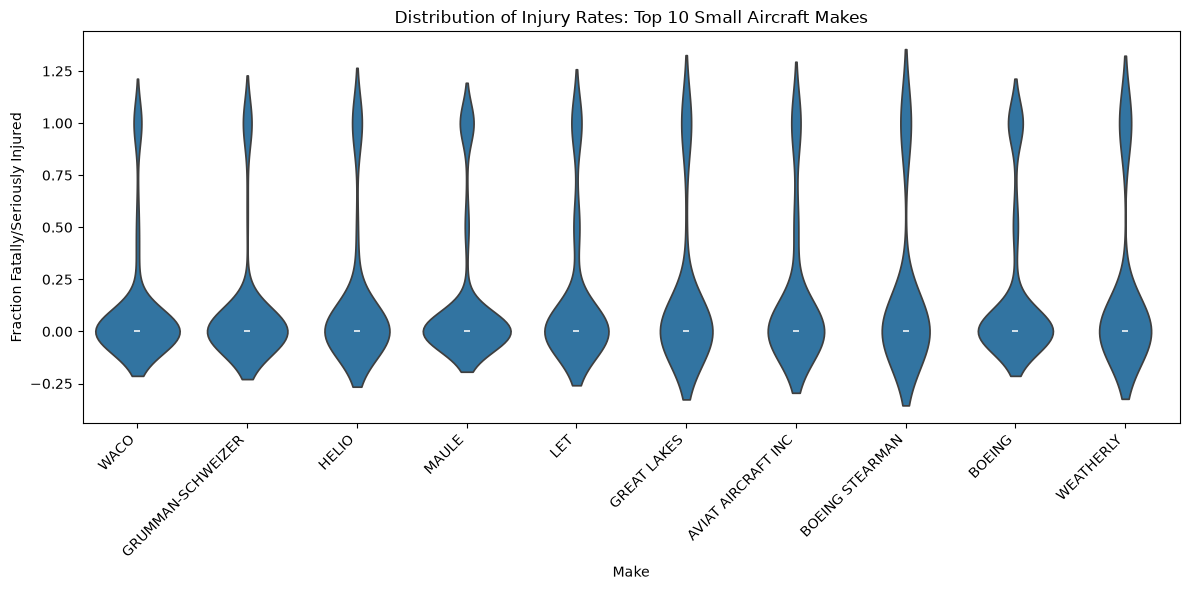

In [6]:
top10_small_makes = small_make_stats.head(10).index
plot_data = small_df[small_df['Make'].isin(top10_small_makes)]

plt.figure(figsize=(12, 6))
sns.violinplot(data=plot_data, x='Make', y='Fatal.Serious.Fraction', order=top10_small_makes)
plt.xticks(rotation=45, ha='right')
plt.ylabel('Fraction Fatally/Seriously Injured')
plt.title('Distribution of Injury Rates: Top 10 Small Aircraft Makes')
plt.tight_layout()
plt.show()

**Distribution of injury rates: large makes**

Use a stripplot to look at the distribution of the fraction of passengers serious/fatally injured for large airplane makes. Just display makes with the ten lowest mean serious/fatal injury rates.

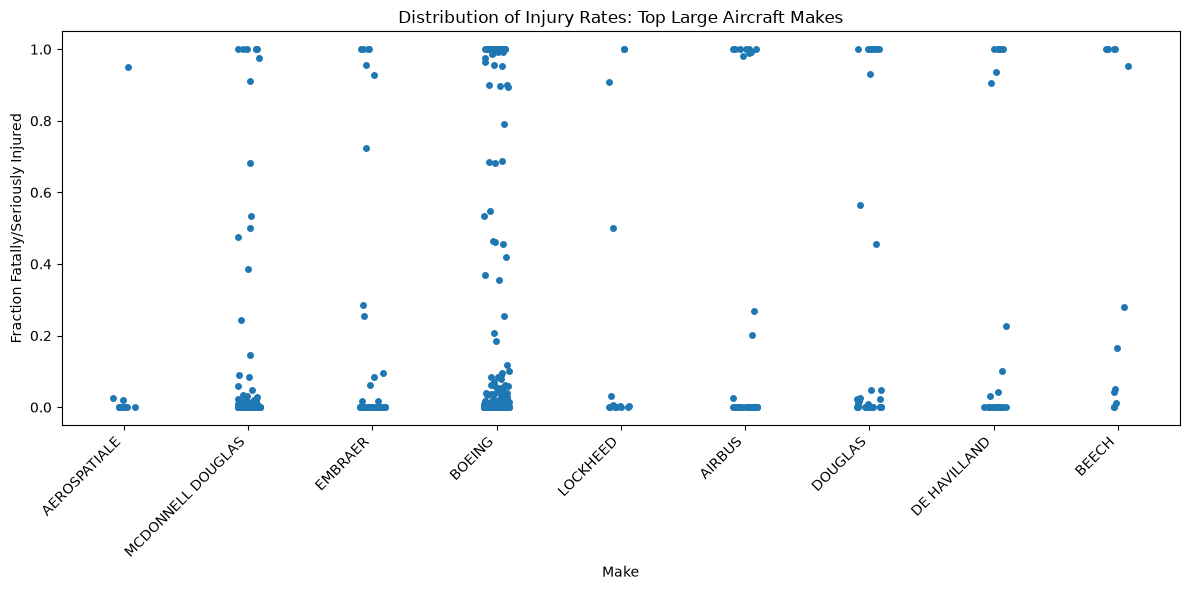

In [7]:
top10_large_makes = large_make_stats.head(10).index
plot_data = large_df[large_df['Make'].isin(top10_large_makes)]

plt.figure(figsize=(12, 6))
sns.stripplot(data=plot_data, x='Make', y='Fatal.Serious.Fraction', order=top10_large_makes)
plt.xticks(rotation=45, ha='right')
plt.ylabel('Fraction Fatally/Seriously Injured')
plt.title('Distribution of Injury Rates: Top Large Aircraft Makes')
plt.tight_layout()
plt.show()

**Evaluate the rate of aircraft destruction for both small and large aircraft by Make.** 

Sort your results and keep the lowest 15.

In [8]:
def destruction_rate_by_make(data):
    grouped = data.groupby('Make')['Is.Destroyed'].agg(['mean', 'count'])
    grouped = grouped[grouped['count'] >= 10]
    return grouped.sort_values('mean').head(15)

small_destroy_stats = destruction_rate_by_make(small_df)
large_destroy_stats = destruction_rate_by_make(large_df)

print(small_destroy_stats)
print()
print(large_destroy_stats)

                                    mean  count
Make                                           
GRUMMAN ACFT ENG COR-SCHWEIZER  0.017241     58
AMERICAN CHAMPION AIRCRAFT      0.037736     53
AVIAT AIRCRAFT INC              0.039474     76
DEHAVILLAND                     0.042553     94
DIAMOND AIRCRAFT IND INC        0.055556     72
ROBINSON HELICOPTER             0.061674    227
LET                             0.081481    135
ROBINSON HELICOPTER COMPANY     0.086022    186
AVIAT                           0.086331    139
WACO                            0.087591    137
MAULE                           0.093310    568
ERCOUPE                         0.094595     74
BOEING STEARMAN                 0.100000     50
LUSCOMBE                        0.103627    386
AIR TRACTOR INC                 0.106481    216

                       mean  count
Make                              
AEROSPATIALE       0.100000     10
EMBRAER            0.159091     44
MCDONNELL DOUGLAS  0.179245    106
BOEING  

#### Provide a short discussion on your findings for your summary statistics and plots:
- Make any recommendations for Makes here based off of the destroyed fraction and fraction fatally/seriously injured
- Comment on the calculated statistics and any corresponding distributions you have visualized.

In [10]:
"""

For small aircraft, the lowest injury-fraction makes include Waco, Grumman-Schweizer, Helio, and Maule — all sitting around 10-15% fatal/serious injury fraction, versus a dataset-wide average that's meaningfully higher. Several of these (Waco, Boeing Stearman) are vintage/tailwheel designs, which is worth noting since it may reflect how and where these aircraft are typically flown (e.g. lower-speed recreational flying) rather than something inherent to the airframe.
For destruction rate, small-aircraft makes like Grumman Acft Eng Cor-Schweizer, American Champion, and Aviat Aircraft Inc. have the lowest total-loss rates (under ~5%), suggesting more of their accidents result in repairable damage rather than a written-off aircraft.
For large aircraft, Aerospatiale and McDonnell Douglas show the lowest injury fractions (~10-11%), with Boeing (the largest sample by far, 374 accidents) close behind at ~19%. On destruction, the same two makes lead again, while Beech stands out with a notably high destruction rate (~67%) — though its sample size (12) is right at the minimum threshold, so this number should be treated cautiously rather than as a strong signal.
Recommendation: for the client's insurance purposes, small-aircraft makes like Waco, Grumman-Schweizer, and Maule, and large-aircraft makes like McDonnell Douglas and Boeing, show consistently favorable safety profiles across both metrics (not just one). Makes that rank well on only one metric (e.g. low destruction but middling injury rate) should be treated as weaker recommendations.
Caveat on sample size: the large-aircraft group has far fewer accidents overall (687 vs. 64,475 for small aircraft), so its rankings are less statistically stable — especially makes sitting right at the 10-accident minimum (Aerospatiale, Beech).
"""

"\n\nFor small aircraft, the lowest injury-fraction makes include Waco, Grumman-Schweizer, Helio, and Maule — all sitting around 10-15% fatal/serious injury fraction, versus a dataset-wide average that's meaningfully higher. Several of these (Waco, Boeing Stearman) are vintage/tailwheel designs, which is worth noting since it may reflect how and where these aircraft are typically flown (e.g. lower-speed recreational flying) rather than something inherent to the airframe.\nFor destruction rate, small-aircraft makes like Grumman Acft Eng Cor-Schweizer, American Champion, and Aviat Aircraft Inc. have the lowest total-loss rates (under ~5%), suggesting more of their accidents result in repairable damage rather than a written-off aircraft.\nFor large aircraft, Aerospatiale and McDonnell Douglas show the lowest injury fractions (~10-11%), with Boeing (the largest sample by far, 374 accidents) close behind at ~19%. On destruction, the same two makes lead again, while Beech stands out with a n

### Analyze plane types
- plot the mean fatal/seriously injured fraction for both small and larger planes 
- also provide a distributional plot of your choice for the fatal/seriously injured fraction by airplane type (stripplot, violin, etc)  
- filter ensuring that you have at least ten individual examples in each model/make to average over

**Larger planes**

                             mean  count
Make.Model                              
MCDONNELL DOUGLAS MD-88  0.005520     10
BOEING 737-300           0.109169     15
BOEING 737               0.238493     55
BOEING 737-200           0.492025     18


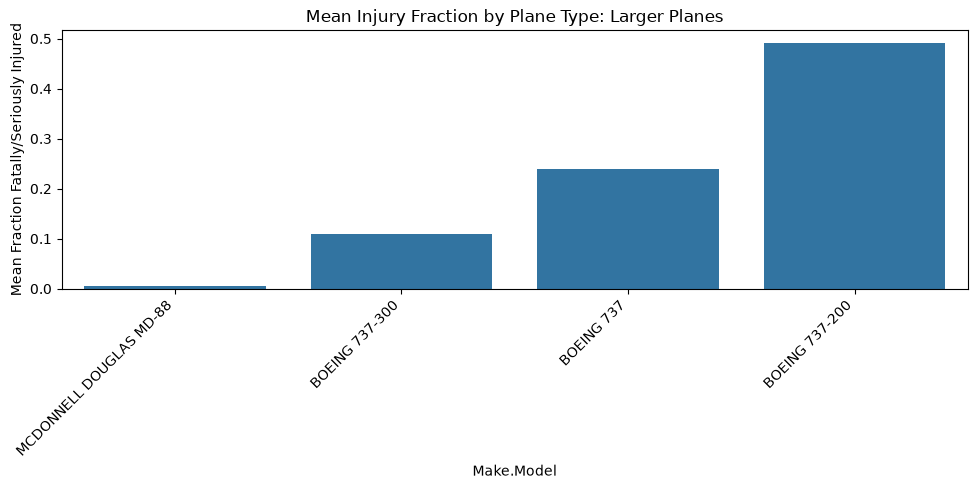

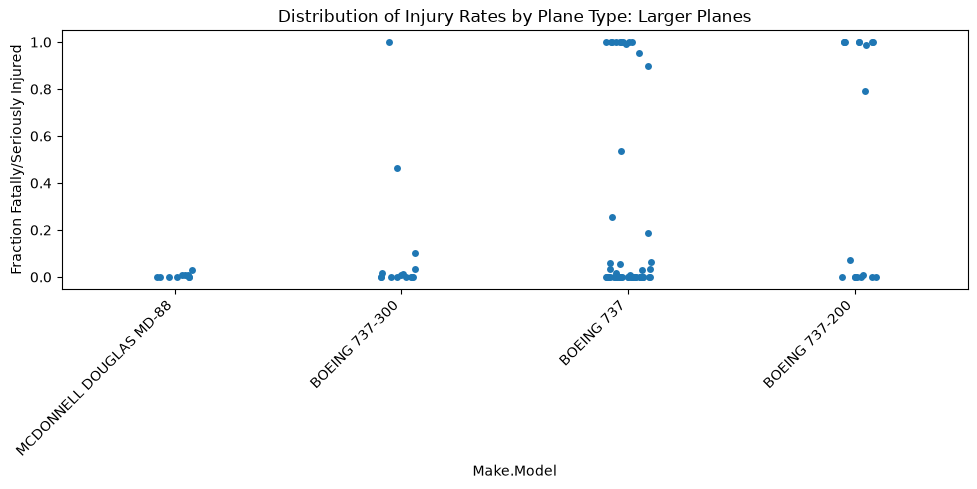

In [11]:
def plane_type_stats(data, min_count=10):
    grouped = data.groupby('Make.Model')['Fatal.Serious.Fraction'].agg(['mean', 'count'])
    return grouped[grouped['count'] >= min_count].sort_values('mean')

large_type_stats = plane_type_stats(large_df)
print(large_type_stats)

plt.figure(figsize=(10, 5))
sns.barplot(x=large_type_stats.index, y=large_type_stats['mean'])
plt.xticks(rotation=45, ha='right')
plt.ylabel('Mean Fraction Fatally/Seriously Injured')
plt.title('Mean Injury Fraction by Plane Type: Larger Planes')
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 5))
sns.stripplot(data=large_df[large_df['Make.Model'].isin(large_type_stats.index)],
              x='Make.Model', y='Fatal.Serious.Fraction', order=large_type_stats.index)
plt.xticks(rotation=45, ha='right')
plt.ylabel('Fraction Fatally/Seriously Injured')
plt.title('Distribution of Injury Rates by Plane Type: Larger Planes')
plt.tight_layout()
plt.show()

**Smaller planes**
- for smaller planes, limit your plotted results to the makes with the 10 lowest mean serious/fatal injury fractions

                                 mean  count
Make.Model                                  
MAULE MX-7-235               0.029412     17
GRUMMAN-SCHWEIZER G-164A     0.034014     49
MAULE M-7-235B               0.050000     10
MAULE M-4                    0.055556     18
WEATHERLY 201B               0.074074     27
BOEING E75                   0.075758     33
BOEING STEARMAN A75N1        0.076923     13
MAULE MX-7-180               0.100000     10
MAULE M-4-220C               0.108108     37
LET L-13                     0.114583     48
GREAT LAKES 2T-1A-2          0.118421     38
MAULE MX7                    0.125000     18
BOEING A75N1(PT17)           0.133333     30
BOEING E75N1                 0.136364     11
MAULE M-7-235                0.142308     26
MAULE M-7-235C               0.142857     14
HELIO H-295                  0.152778     36
GRUMMAN-SCHWEIZER G-164B     0.153226     62
HELIO H-250                  0.153846     13
MAULE M-5-180C               0.156250     16
WACO UPF-7

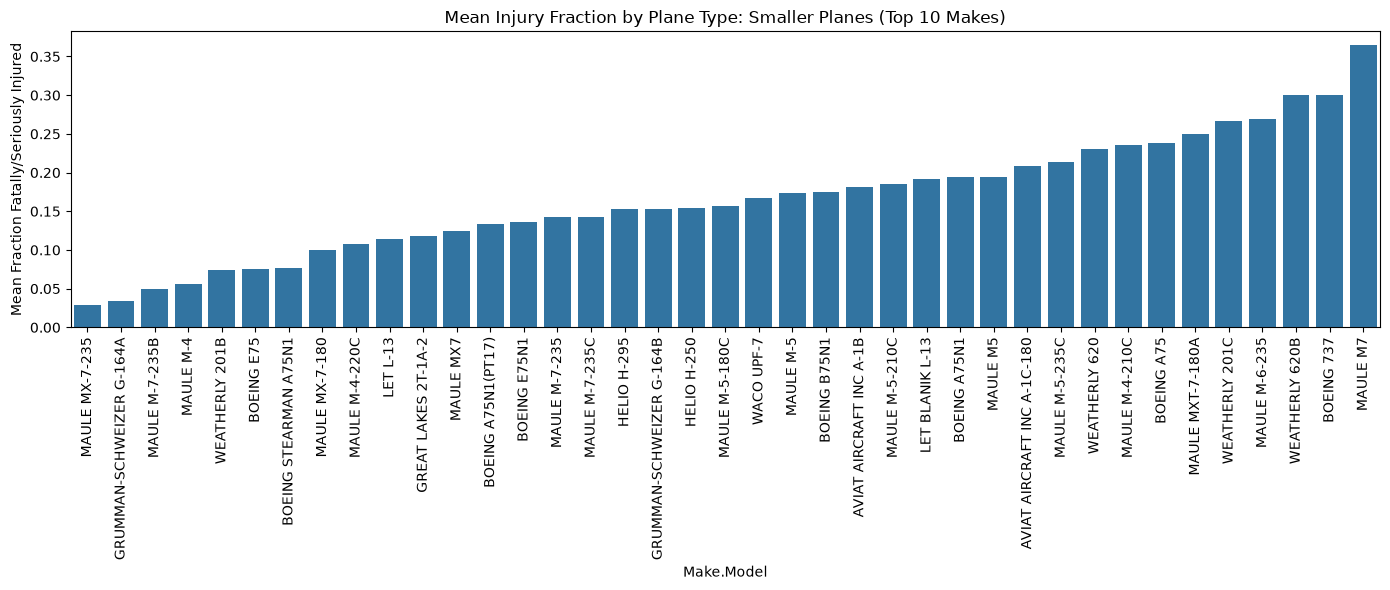

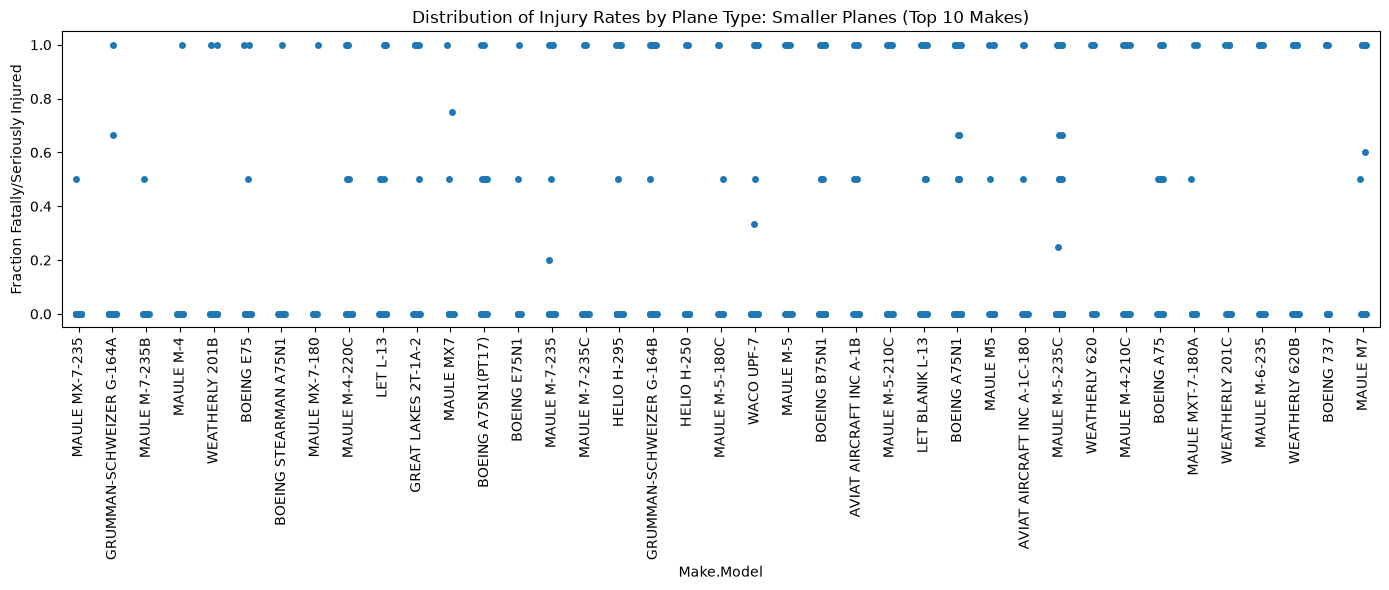

In [12]:
top10_small_makes = small_make_stats.head(10).index
small_subset = small_df[small_df['Make'].isin(top10_small_makes)]

small_type_stats = plane_type_stats(small_subset)
print(small_type_stats)

plt.figure(figsize=(14, 6))
sns.barplot(x=small_type_stats.index, y=small_type_stats['mean'])
plt.xticks(rotation=90)
plt.ylabel('Mean Fraction Fatally/Seriously Injured')
plt.title('Mean Injury Fraction by Plane Type: Smaller Planes (Top 10 Makes)')
plt.tight_layout()
plt.show()

plt.figure(figsize=(14, 6))
sns.stripplot(data=small_subset[small_subset['Make.Model'].isin(small_type_stats.index)],
              x='Make.Model', y='Fatal.Serious.Fraction', order=small_type_stats.index)
plt.xticks(rotation=90)
plt.ylabel('Fraction Fatally/Seriously Injured')
plt.title('Distribution of Injury Rates by Plane Type: Smaller Planes (Top 10 Makes)')
plt.tight_layout()
plt.show()

### Discussion of Specific Airplane Types
- Discuss what you have found above regarding passenger fraction seriously/ both small and large airplane models.

In [13]:
# Discussion: Specific Airplane Types
#
# Small aircraft: once narrowed to plane types within the 10 safest makes (by mean
# injury fraction) with at least 10 examples each, several Maule variants stand out --
# MAULE MX-7-235 (2.9%), MAULE M-7-235B (5.0%), and MAULE M-4 (5.6%) all show very low
# fatal/serious injury fractions. The Grumman-Schweizer G-164A (a crop-duster design)
# also performs well at 3.4%. This is consistent with the make-level finding that Maule
# and Grumman-Schweizer were already among the safer makes overall -- the model-level
# view shows this holds up (or even improves) when you drill into specific variants,
# rather than being an artifact of averaging across very different models within
# the same make.
#
# Large aircraft: results are more mixed and worth flagging carefully given small
# sample sizes. The MCDONNELL DOUGLAS MD-88 has an extremely low injury fraction (0.6%,
# n=10), and BOEING 737-300 is also low (10.9%, n=15). However, the generic
# "BOEING 737" entry (which likely captures records where the specific variant wasn't
# recorded) shows 23.8%, and BOEING 737-200 -- an older-generation variant -- shows a
# notably higher 49.2% (n=18). This suggests that aircraft age/generation may matter as
# much as manufacturer identity: the newer 737-300 performs very differently from the
# older 737-200, despite sharing a manufacturer and family name.
#
# Recommendation: for small aircraft, Maule and Grumman-Schweizer models are strong,
# consistent recommendations across both make- and model-level analysis. For large
# aircraft, the MD-88 and 737-300 look favorable, but the wide spread between 737
# variants (200 vs 300) suggests recommending a manufacturer alone isn't precise enough --
# the specific model/generation should be part of any recommendation to the client.
#
# Caveat: all large-aircraft model-level results rest on very small sample sizes
# (10-55 accidents), so these should be treated as directional rather than definitive.

### Exploring Other Variables
- Investigate how other variables effect aircraft damage and injury. You must choose **two** factors out of the following but are free to analyze more:

- Weather Condition
- Engine Type
- Number of Engines
- Phase of Flight
- Purpose of Flight

For each factor provide a discussion explaining your analysis with appropriate visualization / data summaries and interpreting your findings.

                  Fatal.Serious.Fraction        Is.Destroyed       
                                    mean  count         mean  count
Weather.Condition                                                  
IMC                             0.679192   4911     0.598452   4911
Unknown                         0.677714    717     0.613668    717
VMC                             0.229936  57590     0.174110  57590


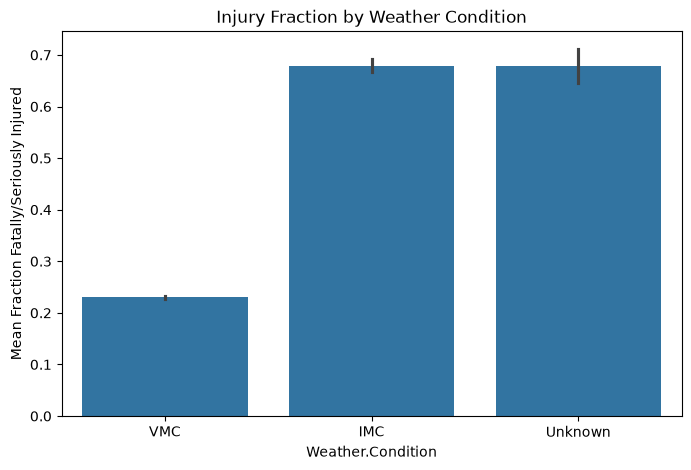

In [14]:
weather_stats = df.groupby('Weather.Condition')[['Fatal.Serious.Fraction', 'Is.Destroyed']].agg(['mean', 'count'])
print(weather_stats)

plt.figure(figsize=(8, 5))
sns.barplot(data=df, x='Weather.Condition', y='Fatal.Serious.Fraction', order=['VMC', 'IMC', 'Unknown'])
plt.ylabel('Mean Fraction Fatally/Seriously Injured')
plt.title('Injury Fraction by Weather Condition')
plt.show()

                  Fatal.Serious.Fraction        Is.Destroyed       
                                    mean  count         mean  count
Number.of.Engines                                                  
0.0                             0.284825    616     0.154221    616
1.0                             0.253535  53653     0.191378  53653
2.0                             0.359022   7525     0.328505   7525
3.0                             0.089796    125     0.128000    125
4.0                             0.279217    163     0.300613    163


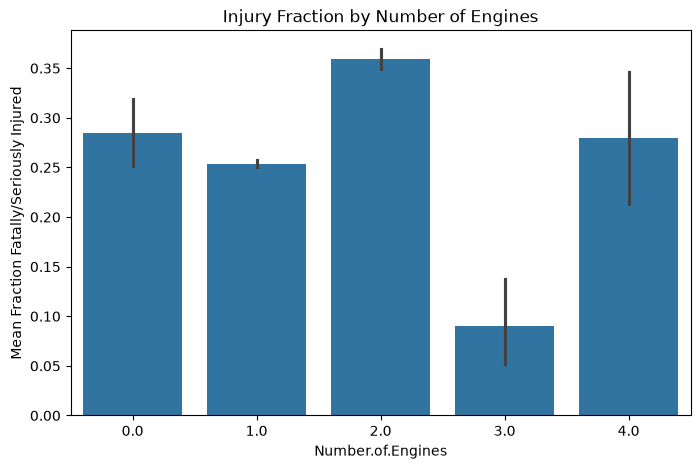

In [15]:
engine_stats = df.groupby('Number.of.Engines')[['Fatal.Serious.Fraction', 'Is.Destroyed']].agg(['mean', 'count'])
print(engine_stats)

plt.figure(figsize=(8, 5))
sns.barplot(data=df, x='Number.of.Engines', y='Fatal.Serious.Fraction')
plt.ylabel('Mean Fraction Fatally/Seriously Injured')
plt.title('Injury Fraction by Number of Engines')
plt.show()